# 🧠 AI-Powered Resume Screening & Candidate Ranking System
### Machine Learning Internship – Task 3

## 📌 Problem Statement

Companies receive a large number of resumes for job openings. 
Manually screening resumes is time-consuming and inefficient.

This project builds an AI-powered resume screening system that:
- analyzes resumes
- matches them with job descriptions
- ranks candidates based on skill relevance
- identifies missing skills

The goal is to assist HR teams in faster and smarter hiring.

In [6]:
import pandas as pd

data = pd.read_csv('archive/Resume Screening.csv')

data.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [8]:
print(data.columns)
data.info()

Index(['Category', 'Resume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


## 🧹 Resume Text Cleaning

In [18]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    # remove URLs
    text = re.sub(r'http\S+', ' ', text)
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text

data['clean_resume'] = data['Resume'].apply(clean_text)

data[['Resume', 'clean_resume']].head()

,Resume,clean_resume
0,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Education Details \r\nMay 2013 to May 2017 B.E...,education details may to may b e uit rgpv data...
2,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...


## 📄 Job Description

In [10]:
job_description = """
Looking for a Machine Learning Engineer with skills in:
Python, SQL, Machine Learning, NLP, Data Analysis, Git
"""

## 🔢 Feature Extraction using TF-IDF

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(
    data['clean_resume'].tolist() + [job_description]
)

## 📊 Resume Matching using Cosine Similarity

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    tfidf_matrix[-1],
    tfidf_matrix[:-1]
)

data['match_score'] = similarity[0] * 100

## 🏆 Candidate Ranking

In [21]:
ranked_data = data.sort_values(by='match_score', ascending=False)

ranked_data[['Category', 'match_score']].head(10)

,Category,match_score
17,Data Science,38.888289
37,Data Science,38.888289
27,Data Science,38.888289
7,Data Science,38.888289
28,Data Science,32.831783
8,Data Science,32.831783
38,Data Science,32.831783
18,Data Science,32.831783
36,Data Science,26.243100
6,Data Science,26.243100


## 🛠️ Skill Extraction

In [22]:
skills = [
    "python",
    "sql",
    "machine learning",
    "deep learning",
    "nlp",
    "data analysis",
    "tensorflow",
    "pandas",
    "numpy",
    "power bi",
    "excel",
    "git",
    "tableau",
    "java",
    "aws"
]

In [23]:
def extract_skills(text):
    
    found_skills = []
    
    text = text.lower()
    
    for skill in skills:
        if skill.lower() in text:
            found_skills.append(skill)
            
    return found_skills

In [24]:
data['skills_found'] = data['clean_resume'].apply(extract_skills)

In [25]:
data[['Category', 'skills_found']].head(10)

,Category,skills_found
0,Data Science,"[python, sql, machine learning, deep learning,..."
1,Data Science,"[python, machine learning, git, aws]"
2,Data Science,"[python, sql, machine learning, deep learning,..."
3,Data Science,"[python, sql, machine learning, deep learning,..."
4,Data Science,"[python, data analysis, java]"
5,Data Science,"[python, machine learning, excel]"
6,Data Science,"[python, machine learning, excel, tableau]"
7,Data Science,"[python, sql, machine learning, deep learning,..."
8,Data Science,"[python, sql, machine learning, deep learning,..."
9,Data Science,"[python, machine learning, nlp, data analysis,..."


## ⚠️ Skill Gap Analysis

In [26]:
required_skills = [
    "python",
    "sql",
    "machine learning",
    "nlp",
    "git"
]

def missing_skills(found_skills):
    
    missing = list(set(required_skills) - set(found_skills))
    
    return missing

data['missing_skills'] = data['skills_found'].apply(missing_skills)

In [27]:
data[
    ['Category', 'skills_found', 'missing_skills']
].head(10)

,Category,skills_found,missing_skills
0,Data Science,"[python, sql, machine learning, deep learning,...",[nlp]
1,Data Science,"[python, machine learning, git, aws]","[sql, nlp]"
2,Data Science,"[python, sql, machine learning, deep learning,...",[nlp]
3,Data Science,"[python, sql, machine learning, deep learning,...",[]
4,Data Science,"[python, data analysis, java]","[nlp, sql, git, machine learning]"
5,Data Science,"[python, machine learning, excel]","[sql, git, nlp]"
6,Data Science,"[python, machine learning, excel, tableau]","[sql, git, nlp]"
7,Data Science,"[python, sql, machine learning, deep learning,...",[git]
8,Data Science,"[python, sql, machine learning, deep learning,...",[git]
9,Data Science,"[python, machine learning, nlp, data analysis,...","[sql, git]"


## 📈 Top Candidate Match Scores

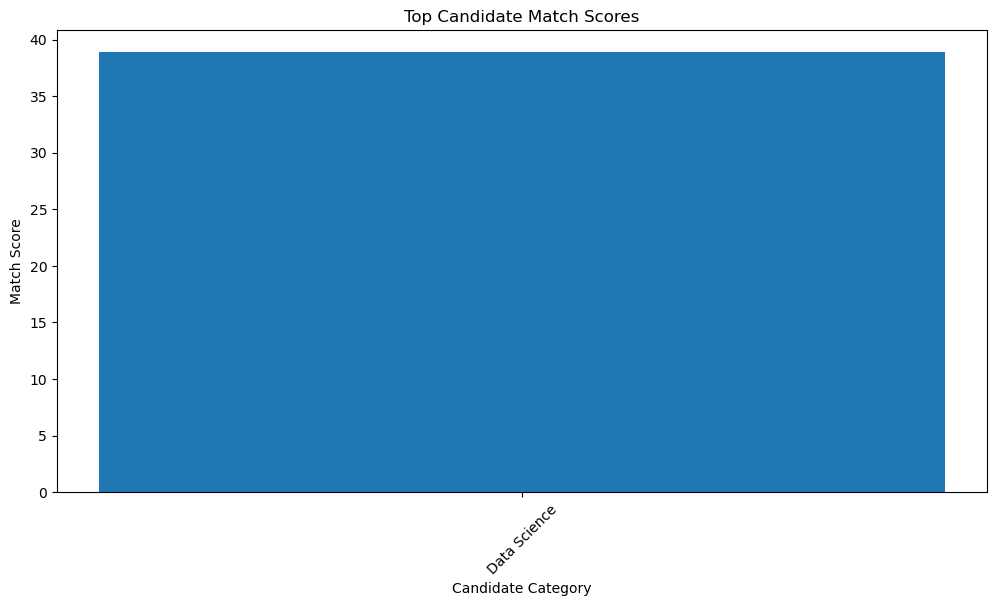

In [28]:
import matplotlib.pyplot as plt

top_candidates = ranked_data.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_candidates['Category'],
    top_candidates['match_score']
)

plt.title("Top Candidate Match Scores")
plt.xlabel("Candidate Category")
plt.ylabel("Match Score")

plt.xticks(rotation=45)

plt.show()

In [ ]:
## 🛠️ Most Common Skills in Resumes

In [29]:
all_skills = []

for skills_list in data['skills_found']:
    all_skills.extend(skills_list)

from collections import Counter

skill_counts = Counter(all_skills)

top_skills = skill_counts.most_common(10)

skills_names = [item[0] for item in top_skills]
skills_values = [item[1] for item in top_skills]

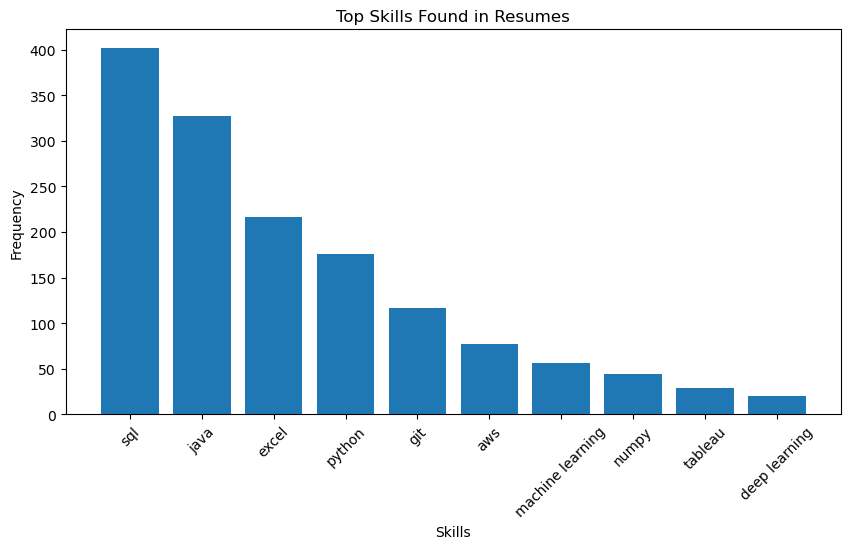

In [30]:
plt.figure(figsize=(10,5))

plt.bar(skills_names, skills_values)

plt.title("Top Skills Found in Resumes")
plt.xlabel("Skills")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## 🏆 Top Candidate Recommendation

In [32]:
ranked_data = data.sort_values(by='match_score', ascending=False)

In [33]:
best_candidate = ranked_data.iloc[0]

print("Recommended Candidate Category:")
print(best_candidate['Category'])

print("\nMatch Score:")
print(round(best_candidate['match_score'], 2), "%")

print("\nSkills Found:")
print(best_candidate['skills_found'])

print("\nMissing Skills:")
print(best_candidate['missing_skills'])

Recommended Candidate Category:
Data Science

Match Score:
38.89 %

Skills Found:
['python', 'sql', 'machine learning', 'deep learning', 'nlp', 'tensorflow', 'pandas', 'numpy', 'java']

Missing Skills:
['git']


## 🚀 Final Resume Screening Results

In [34]:
ranked_data[
    [
        'Category',
        'match_score',
        'skills_found',
        'missing_skills'
    ]
].head(10)

,Category,match_score,skills_found,missing_skills
17,Data Science,38.888289,"[python, sql, machine learning, deep learning,...",[git]
37,Data Science,38.888289,"[python, sql, machine learning, deep learning,...",[git]
27,Data Science,38.888289,"[python, sql, machine learning, deep learning,...",[git]
7,Data Science,38.888289,"[python, sql, machine learning, deep learning,...",[git]
28,Data Science,32.831783,"[python, sql, machine learning, deep learning,...",[git]
8,Data Science,32.831783,"[python, sql, machine learning, deep learning,...",[git]
38,Data Science,32.831783,"[python, sql, machine learning, deep learning,...",[git]
18,Data Science,32.831783,"[python, sql, machine learning, deep learning,...",[git]
36,Data Science,26.243100,"[python, machine learning, excel, tableau]","[sql, git, nlp]"
6,Data Science,26.243100,"[python, machine learning, excel, tableau]","[sql, git, nlp]"


## 💡 Business Impact

This AI-powered system can help companies:

- Automate resume screening
- Reduce recruiter workload
- Shortlist candidates faster
- Improve hiring efficiency
- Identify skill gaps automatically

The project demonstrates how NLP and Machine Learning can optimize HR operations and recruitment workflows.

## 🏁 Conclusion

This project successfully developed an AI-powered resume screening system capable of:
- analyzing resumes
- matching them with job descriptions
- ranking candidates
- identifying missing skills

The system can help HR teams automate hiring workflows and improve recruitment efficiency.